#  Kapitel 1: Introduktion till maskininlärning

##  Översikt

Detta notebook innehåller **all kod från Kapitel 1** i boken "LÄR DIG AI FRÅN GRUNDEN - TILLÄMPAD MASKININLÄRNING MED PYTHON".

###  Innehåll:
- **1.1** Artificiell intelligens (AI), maskininlärning (ML) och djupinlärning (DL)
- **1.2** Fyra problemkategorier inom maskininlärning
- **1.3** Fundamentala koncept
  - Träningsdata, valideringsdata och testdata
  - K-delad korsvalidering
  - RMSE (Root Mean Squared Error)
  - Hyperparametrar och parametrar
  - Grid search
  - Kategorisk data
  - Feature engineering
- **1.4** Tvärsnittsdata, tidsseriedata och paneldata

---

**Författare**: Antonio Prgomet, Terese Johnson, Amanda Solberg, Linus Rundberg Streuli  
**Källa**: LÄR DIG AI FRÅN GRUNDEN - TILLÄMPAD MASKININLÄRNING MED PYTHON

## 1.2 Fyra problemkategorier inom maskininlärning

###  Exempel: Regression och klassificering

Vi börjar med att visa exempel på regression och klassificering från boken.

In [23]:
# Exempel från boken: Regression data
# Importera pandas bibliotek för datahantering
import pandas as pd

# Skapa en dictionary med regression data
# "Inkomst (y)" är utdatan (target) - kontinuerlig variabel
# "Ålder (x)" är indatan (feature) - oberoende variabel
regression_data = {
    "Inkomst (y)": [58500, 42000, 34000, 39000],  # y-värden (beroende variabel)
    "Ålder (x)": [58, 29, 35, 42]                 # x-värden (oberoende variabel)
}

# Konvertera dictionary till pandas DataFrame för enklare datahantering
df_reg = pd.DataFrame(regression_data)

# Skriv ut information om datan
print(" Regression Data:")
print(df_reg)  # Visa hela DataFrame
print(f"\nData shape: {df_reg.shape}")  # Visa dimensioner (rader, kolumner)
print("\nDetta är ett regressionsproblem eftersom utdatan (inkomst) är kontinuerlig.")

 Regression Data:
   Inkomst (y)  Ålder (x)
0        58500         58
1        42000         29
2        34000         35
3        39000         42

Data shape: (4, 2)

Detta är ett regressionsproblem eftersom utdatan (inkomst) är kontinuerlig.


In [24]:
# Exempel från boken: Klassificering data
# Skapa en dictionary med klassificeringsdata
# "Kön (y)" är utdatan (target) - diskret variabel med kategorier
# "Inkomst (x1)" och "Ålder (x2)" är indata (features) - oberoende variabler
classification_data = {
    "Kön (y)": ["Man", "Kvinna", "Man", "Kvinna"],  # y-värden (beroende variabel, diskret)
    "Inkomst (x1)": [84000, 36750, 33000, 53000],    # x1-värden (oberoende variabel)
    "Ålder (x2)": [58, 29, 35, 42]                   # x2-värden (oberoende variabel)
}

# Konvertera dictionary till pandas DataFrame
df_classification = pd.DataFrame(classification_data)

# Skriv ut information om datan
print(" Klassificering Data:")
print(df_classification)  # Visa hela DataFrame
print(f"\nData shape: {df_classification.shape}")  # Visa dimensioner
print("\nDetta är ett klassificeringsproblem eftersom utdatan (kön) antar diskreta värden.")

 Klassificering Data:
  Kön (y)  Inkomst (x1)  Ålder (x2)
0     Man         84000          58
1  Kvinna         36750          29
2     Man         33000          35
3  Kvinna         53000          42

Data shape: (4, 3)

Detta är ett klassificeringsproblem eftersom utdatan (kön) antar diskreta värden.


## 1.3.1 Träningsdata, valideringsdata och testdata

###  Datauppdelning med diabetes-dataset

Vi använder diabetes-datasetet från scikit-learn för att demonstrera datauppdelning.

In [25]:
# Importera nödvändiga bibliotek
# load_diabetes: Funktion för att ladda diabetes-datasetet från scikit-learn
from sklearn.datasets import load_diabetes
# train_test_split: Funktion för att dela upp data i träning och test
from sklearn.model_selection import train_test_split

# Ladda diabetes-datasetet
# as_frame=True: Returnerar data som pandas DataFrame istället för numpy arrays
diabetes = load_diabetes(as_frame=True)
# diabetes.frame: Hämta DataFrame med all data (features + target)
df = diabetes.frame

# Skriv ut information om datasetet
print(" Diabetes Dataset - Översikt:")
print(f"Antal observationer: {len(df)}")  # Antal rader i datasetet
print(f"Antal features: {len(df.columns)}")  # Antal kolumner (features + target)
print(f"Target variabel: 'target'")  # Namn på target-variabeln (diabetes dataset har ingen target_names)
print("\nFörsta 5 rader:")  # Visa de första 5 raderna för att se datan
print(df.head())  # head() visar första 5 raderna som standard

 Diabetes Dataset - Översikt:
Antal observationer: 442
Antal features: 11
Target variabel: 'target'

Första 5 rader:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [26]:
# Förbereder data för modellering
# Separera features (X) och target (y)
# drop(columns='target'): Ta bort 'target'-kolumnen från DataFrame, behåll bara features
X = df.drop(columns='target')  # Features (oberoende variabler)
# df['target']: Välj bara 'target'-kolumnen som vår beroende variabel
y = df['target']               # Target (beroende variabel)

# Skriv ut information om datauppdelningen
print(" Datauppdelning:")
print(f"X (features) shape: {X.shape}")  # Antal rader och kolumner för features
print(f"y (target) shape: {y.shape}")    # Antal rader för target (1 kolumn)

# Första uppdelning: 80% träning+validering, 20% test
# train_test_split: Delar upp data slumpmässigt
# test_size=0.2: 20% av data går till test
# random_state=42: Säkerställer att vi får samma uppdelning varje gång (reproducerbarhet)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Andra uppdelning: 75% träning, 25% validering (av de 80%)
# test_size=0.25: 25% av de återstående 80% går till validering
# Detta ger oss: 60% träning, 20% validering, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

# Skriv ut slutlig datauppdelning
print("\n Datauppdelning 60-20-20:")
# X_train.shape[0]: Antal rader i träningsdata
# len(X): Totalt antal rader i originaldata
print(f"Träning: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validering: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

 Datauppdelning:
X (features) shape: (442, 10)
y (target) shape: (442,)

 Datauppdelning 60-20-20:
Träning: 264 (59.7%)
Validering: 89 (20.1%)
Test: 89 (20.1%)


###  Komplett ML-pipeline

Vi demonstrerar en komplett pipeline med träning, validering och test enligt boken.

In [27]:
# Importera modeller och metrics
# LinearRegression: Linjär regressionsmodell från scikit-learn
from sklearn.linear_model import LinearRegression
# DecisionTreeRegressor: Beslutsträd för regression
from sklearn.tree import DecisionTreeRegressor
# root_mean_squared_error: Funktion för att beräkna RMSE
from sklearn.metrics import root_mean_squared_error

# Förklara ML-pipeline processen
print(" Komplett ML-pipeline:")
print("1. Träna olika modeller på träningsdatan")
print("2. Utvärdera modellerna på valideringsdatan och välj den bäst presterande")
print("3. Om prestationen är bra nog, träna om den bäst presterande modellen på tränings- och valideringsdatan")
print("4. Träna om modellen på hela datasetet innan vi börjar använda den skarpt")

# Steg 1: Träna två modeller på träningsdatan
# Skapa instanser av modellerna
linreg = LinearRegression()  # Skapa linjär regressionsmodell
tree = DecisionTreeRegressor(random_state=42)  # Skapa beslutsträd med fixerad random_state

# Träna modellerna på träningsdata
# fit(): Tränar modellen på givna features (X_train) och target (y_train)
linreg.fit(X_train, y_train)  # Träna linjär regression
tree.fit(X_train, y_train)    # Träna beslutsträd

# Bekräfta att modellerna är tränade
print(f"\n Steg 1: Modeller tränade")
# type(linreg).__name__: Hämtar namnet på modellklassen
print(f"Linear Regression: {type(linreg).__name__}")
print(f"Decision Tree: {type(tree).__name__}")

 Komplett ML-pipeline:
1. Träna olika modeller på träningsdatan
2. Utvärdera modellerna på valideringsdatan och välj den bäst presterande
3. Om prestationen är bra nog, träna om den bäst presterande modellen på tränings- och valideringsdatan
4. Träna om modellen på hela datasetet innan vi börjar använda den skarpt

 Steg 1: Modeller tränade
Linear Regression: LinearRegression
Decision Tree: DecisionTreeRegressor


In [28]:
# Steg 2: Utvärdera modellerna på valideringsdatan och välj den bäst presterande
# predict(): Använder tränade modeller för att göra prediktioner på valideringsdata
# root_mean_squared_error(): Beräknar RMSE mellan verkliga värden (y_val) och predikterade värden
rmse_linreg = root_mean_squared_error(y_val, linreg.predict(X_val))  # RMSE för linjär regression
rmse_tree = root_mean_squared_error(y_val, tree.predict(X_val))      # RMSE för beslutsträd

# Skriv ut utvärderingsresultaten
print(" Steg 2: Utvärdering på valideringsdata")
print(f"RMSE på validering - Linjär Regression: {rmse_linreg:.2f}")  # Lägre RMSE = bättre
print(f"RMSE på validering - Beslutsträd: {rmse_tree:.2f}")

# Välj den bäst presterande modellen på valideringsdatan
# Jämför RMSE-värden - lägre RMSE betyder bättre prestanda
if rmse_linreg < rmse_tree:
    # Om linjär regression har lägre RMSE, välj den
    best_model = LinearRegression()  # Skapa ny instans av bästa modellen
    best_model_name = "Linjär Regression"
else:
    # Om beslutsträd har lägre RMSE, välj den
    best_model = DecisionTreeRegressor(random_state=42)  # Skapa ny instans med samma random_state
    best_model_name = "Beslutsträd"

# Skriv ut vilken modell som valdes
print(f"\n Bästa modell baserat på validering: {best_model_name}")

 Steg 2: Utvärdering på valideringsdata
RMSE på validering - Linjär Regression: 51.19
RMSE på validering - Beslutsträd: 65.81

 Bästa modell baserat på validering: Linjär Regression


In [29]:
# Steg 3: Träna om den bäst presterande modellen på tränings- och valideringsdatan
# fit(): Tränar om den bästa modellen på hela tränings- och valideringsdatan (80% av originaldata)
# X_train_full: Kombinerad träning + validering data (features)
# y_train_full: Kombinerad träning + validering data (target)
best_model.fit(X_train_full, y_train_full)

# Utvärdera modellen på testdatan (20% av originaldata som inte använts tidigare)
# predict(): Gör prediktioner på testdata
# root_mean_squared_error(): Beräknar RMSE mellan verkliga testvärden och predikterade testvärden
rmse_test = root_mean_squared_error(y_test, best_model.predict(X_test))

# Skriv ut resultaten från steg 3
print(" Steg 3: Bästa modell tränad om på träning + validering")
print(f"Bästa modell baserat på validering: {best_model_name}")
print(f"RMSE på testdatan: {rmse_test:.2f}")  # Detta är vår slutliga utvärdering

 Steg 3: Bästa modell tränad om på träning + validering
Bästa modell baserat på validering: Linjär Regression
RMSE på testdatan: 53.85


In [30]:
# Steg 4: Träna om modellen på hela datasetet innan vi börjar använda den skarpt
# fit(): Tränar om modellen på hela originaldatasetet (100% av data)
# X: Alla features från hela datasetet
# y: Alla target-värden från hela datasetet
best_model.fit(X, y)

# Skriv ut information om den slutliga modellen
print(" Steg 4: Modell tränad om på hela datasetet")
print(f"Final modell: {best_model_name}")
print(f"Modell parametrar:")
# get_params(): Hämtar alla hyperparametrar för modellen
print(best_model.get_params())

 Steg 4: Modell tränad om på hela datasetet
Final modell: Linjär Regression
Modell parametrar:
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


## 1.3.2 K-delad korsvalidering

###  Cross-validation demonstration

Vi demonstrerar k-delad korsvalidering med olika modeller.

In [31]:
# Importera nödvändiga bibliotek
import numpy as np  # Numerisk beräkning
from sklearn.datasets import load_diabetes  # Diabetes dataset
from sklearn.model_selection import train_test_split  # Datauppdelning
from sklearn.linear_model import LinearRegression  # Linjär regression
from sklearn.svm import LinearSVR  # Support Vector Regression
from sklearn.model_selection import cross_validate  # Korsvalidering

# Ladda data igen för korsvalidering
# return_X_y=True: Returnerar X och y som separata arrays istället för Bunch-objekt
X, y = load_diabetes(return_X_y=True)
# Dela upp data i träning och test (80% träning, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Förklara korsvalideringsprocessen
print(" K-delad korsvalidering:")
print("Data delas upp i k lika stora delar (folds)")
print("Modellen tränas k gånger, varje gång med k-1 folds som träning och 1 fold som validering")
print("Varje fold används exakt en gång som validering")

 K-delad korsvalidering:
Data delas upp i k lika stora delar (folds)
Modellen tränas k gånger, varje gång med k-1 folds som träning och 1 fold som validering
Varje fold används exakt en gång som validering


In [32]:
# Skapa modeller för jämförelse
lr = LinearRegression()  # Skapa linjär regressionsmodell
svr = LinearSVR(random_state=42)  # Skapa Support Vector Regression med fixerad random_state

print(" Korsvalidering - Jämförelse av modeller:")

# Korsvalidering för Linear Regression
# cross_validate(): Utför k-fold korsvalidering
# cv=5: Delar data i 5 folds
# scoring='neg_mean_squared_error': Använder negativ MSE som scoring (scikit-learn konvention)
cv_results_lr = cross_validate(lr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
# np.sqrt(-cv_results_lr['test_score']): Konverterar negativ MSE till RMSE
rmse_lr = np.sqrt(-cv_results_lr['test_score'])

print(f"\n Linear Regression:")
print(f"RMSE för varje fold: {rmse_lr}")  # RMSE för varje av de 5 foldsen
print(f"Genomsnittlig RMSE: {rmse_lr.mean():.4f} (+/- {rmse_lr.std() * 2:.4f})")  # Medel ± 2*standardavvikelse

# Korsvalidering för SVR
# Samma process för Support Vector Regression
cv_results_svr = cross_validate(svr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_svr = np.sqrt(-cv_results_svr['test_score'])

print(f"\n Linear SVR:")
print(f"RMSE för varje fold: {rmse_svr}")
print(f"Genomsnittlig RMSE: {rmse_svr.mean():.4f} (+/- {rmse_svr.std() * 2:.4f})")

# Jämförelse av modellerna
print(f"\n Jämförelse:")
# Jämför genomsnittlig RMSE - lägre är bättre
if rmse_lr.mean() < rmse_svr.mean():
    print(f"Linear Regression presterar bättre (RMSE: {rmse_lr.mean():.4f} vs {rmse_svr.mean():.4f})")
else:
    print(f"Linear SVR presterar bättre (RMSE: {rmse_svr.mean():.4f} vs {rmse_lr.mean():.4f})")

 Korsvalidering - Jämförelse av modeller:

 Linear Regression:
RMSE för varje fold: [52.53034465 58.93522481 52.08727478 56.50041896 59.80716652]
Genomsnittlig RMSE: 55.9721 (+/- 6.3690)

 Linear SVR:
RMSE för varje fold: [ 99.89104783  93.19016071  93.70027682 106.20394259  74.17939188]
Genomsnittlig RMSE: 93.4330 (+/- 21.4595)

 Jämförelse:
Linear Regression presterar bättre (RMSE: 55.9721 vs 93.4330)


## 1.3.3 RMSE (Root Mean Squared Error)

###  Beräkning av RMSE

RMSE är ett vanligt mått för att utvärdera regressionsmodeller.

In [33]:
# Exempel på RMSE-beräkning
# Skapa exempeldata för att demonstrera RMSE-beräkning
y_true = [4, 10, 8]  # Verkliga värden (ground truth)
y_pred = [2, 13, 5]  # Predikterade värden från modellen

# Beräkna RMSE manuellt
from sklearn.metrics import mean_squared_error  # Funktion för att beräkna MSE
import numpy as np  # Numerisk beräkning

# mean_squared_error(): Beräknar Mean Squared Error mellan verkliga och predikterade värden
mse = mean_squared_error(y_true, y_pred)
# np.sqrt(): Tar kvadratroten för att få RMSE från MSE
rmse = np.sqrt(mse)

# Skriv ut resultaten
print(" RMSE Exempel:")
print(f"Verkliga värden (y_true): {y_true}")
print(f"Predikterade värden (y_pred): {y_pred}")
print(f"\nBeräkning:")
print(f"MSE = {mse:.4f}")  # Mean Squared Error
print(f"RMSE = √{mse:.4f} = {rmse:.4f}")  # Root Mean Squared Error

# Visa skillnaderna för varje observation
print(f"\n Skillnader:")
# enumerate(): Ger både index och värde från listan
# zip(): Kombinerar två listor element för element
for i, (true_val, pred_val) in enumerate(zip(y_true, y_pred)):
    diff = true_val - pred_val  # Beräkna skillnad (residual)
    print(f"Observation {i+1}: {true_val} - {pred_val} = {diff}")

 RMSE Exempel:
Verkliga värden (y_true): [4, 10, 8]
Predikterade värden (y_pred): [2, 13, 5]

Beräkning:
MSE = 7.3333
RMSE = √7.3333 = 2.7080

 Skillnader:
Observation 1: 4 - 2 = 2
Observation 2: 10 - 13 = -3
Observation 3: 8 - 5 = 3


## 1.3.4 Hyperparametrar och parametrar

###  Exempel: Linear Regression med olika hyperparametrar

Vi demonstrerar skillnaden mellan hyperparametrar (som styr hur vi lär oss) och parametrar (som är vad vi lär oss).

In [34]:
# Skapa exempeldata för demonstration av hyperparametrar vs parametrar
# Skapa en dictionary med x och y värden för linjär regression
example_data = {
    "y": [-10, 3, 2, 7, -9, 10, 9, 7, 4, 7, 3, 2, -4, -5, -9, -4],  # Target-variabel
    "x": [-3, 0, 1, 2, 4, 2, 3, 5, 7, 8, 9, 6, -2, -5, -1, -2]      # Feature-variabel
}
# Konvertera till pandas DataFrame för enklare hantering
example_df = pd.DataFrame(example_data)

# Visa information om datan
print(" Exempeldata:")
print(example_df.head())  # Visa första 5 raderna
print(f"\nData shape: {example_df.shape}")  # Visa dimensioner (rader, kolumner)

 Exempeldata:
    y  x
0 -10 -3
1   3  0
2   2  1
3   7  2
4  -9  4

Data shape: (16, 2)


In [35]:
# Modell 1: Med intercept (fit_intercept=True)
# LinearRegression(fit_intercept=True): Skapar modell som lär sig både intercept och slope
lin_reg_1 = LinearRegression(fit_intercept=True)
# fit(): Tränar modellen på data
# example_df[['x']]: Väljer x-kolumnen som feature (dubbel brackets för DataFrame)
# example_df['y']: Väljer y-kolumnen som target
lin_reg_1.fit(example_df[['x']], example_df['y'])

# Modell 2: Utan intercept (fit_intercept=False)
# LinearRegression(fit_intercept=False): Skapar modell som bara lär sig slope (intercept = 0)
lin_reg_2 = LinearRegression(fit_intercept=False)
# Tränar modellen på samma data
lin_reg_2.fit(example_df[['x']], example_df['y'])

# Jämför hyperparametrar och parametrar
print(" Hyperparametrar vs Parametrar:")
print("\n Modell 1 (med intercept):")
print(f"Hyperparameter fit_intercept: {lin_reg_1.fit_intercept}")  # Hyperparameter (satt före träning)
print(f"Parameter intercept: {lin_reg_1.intercept_:.4f}")  # Parameter (lärd under träning)
print(f"Parameter slope: {lin_reg_1.coef_[0]:.4f}")  # Parameter (lärd under träning)

print("\n Modell 2 (utan intercept):")
print(f"Hyperparameter fit_intercept: {lin_reg_2.fit_intercept}")  # Hyperparameter
print(f"Parameter intercept: {lin_reg_2.intercept_:.4f}")  # Parameter (alltid 0 när fit_intercept=False)
print(f"Parameter slope: {lin_reg_2.coef_[0]:.4f}")  # Parameter (lärd under träning)

 Hyperparametrar vs Parametrar:

 Modell 1 (med intercept):
Hyperparameter fit_intercept: True
Parameter intercept: -1.1295
Parameter slope: 0.9139

 Modell 2 (utan intercept):
Hyperparameter fit_intercept: False
Parameter intercept: 0.0000
Parameter slope: 0.7982


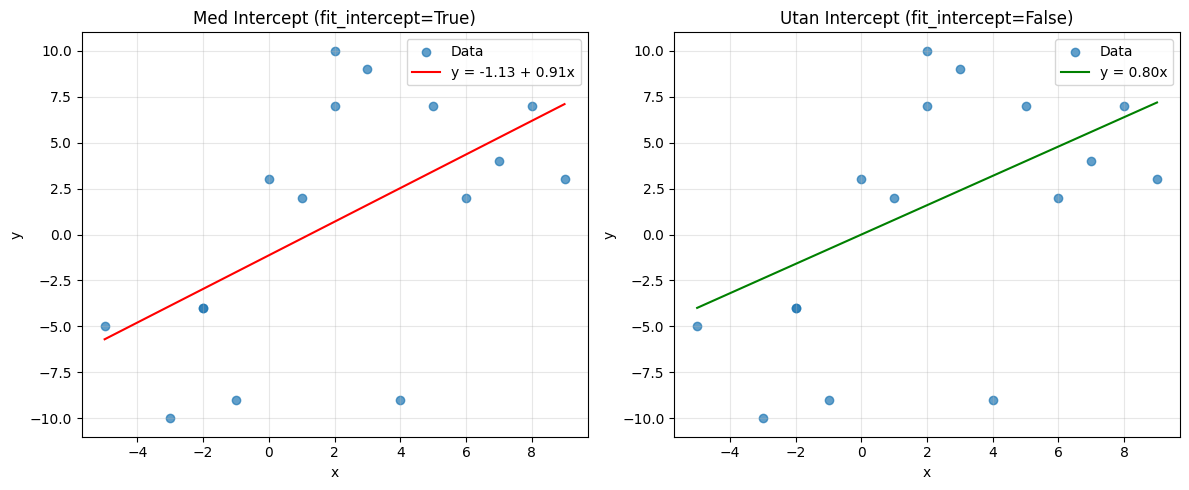

In [36]:
# Visualisera skillnaden
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(example_df['x'], example_df['y'], alpha=0.7, label='Data')
x_range = np.linspace(example_df['x'].min(), example_df['x'].max(), 100)
plt.plot(x_range, lin_reg_1.intercept_ + lin_reg_1.coef_[0] * x_range, 
         'r-', label=f'y = {lin_reg_1.intercept_:.2f} + {lin_reg_1.coef_[0]:.2f}x')
plt.title('Med Intercept (fit_intercept=True)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(example_df['x'], example_df['y'], alpha=0.7, label='Data')
plt.plot(x_range, lin_reg_2.coef_[0] * x_range, 
         'g-', label=f'y = {lin_reg_2.coef_[0]:.2f}x')
plt.title('Utan Intercept (fit_intercept=False)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.3.5 Grid Search

###  Automatisk hyperparameteroptimering

GridSearchCV låter oss automatiskt hitta de bästa hyperparametrarna.

In [37]:
# Skapa GridSearchCV för att hitta bästa hyperparametrar
from sklearn.model_selection import GridSearchCV  # Importera GridSearchCV
from sklearn.linear_model import LinearRegression  # Importera LinearRegression

# Skapa basmodell som ska optimeras
model = LinearRegression()
# Definiera hyperparametrar att testa
hyperparameters = {'fit_intercept': [True, False]}  # Dictionary med hyperparametrar och värden att testa

# Skapa GridSearchCV-objekt
# estimator=model: Basmodellen som ska optimeras
# param_grid=hyperparameters: Hyperparametrar att testa
# scoring='neg_mean_squared_error': Använder negativ MSE som scoring (scikit-learn konvention)
# cv=2: 2-fold korsvalidering för varje hyperparameter-kombination
grid_search = GridSearchCV(
    estimator=model,
    param_grid=hyperparameters, 
    scoring='neg_mean_squared_error',
    cv=2
)

# Träna GridSearchCV på data
# fit(): Testar alla hyperparameter-kombinationer och väljer den bästa
grid_search.fit(example_df[['x']], example_df['y'])

# Visa resultaten
print(" GridSearchCV Resultat:")
print(f"Bästa hyperparametrar: {grid_search.best_params_}")  # Bästa hyperparametrarna
print(f"Bästa cross-validation MSE: {-grid_search.best_score_:.4f}")  # Bästa MSE (negativ, så vi tar -)

# Hämta den bästa modellen
best_model = grid_search.best_estimator_  # Den bästa tränade modellen
print(f"\n Bästa modellens parametrar:")
print(f"Intercept: {best_model.intercept_:.4f}")  # Intercept från bästa modellen
print(f"Slope: {best_model.coef_[0]:.4f}")  # Slope från bästa modellen

# Visa alla resultat från alla hyperparameter-kombinationer
print(f"\n Alla resultat:")
# enumerate(): Ger både index och värde
# grid_search.cv_results_['params']: Lista med alla testade hyperparameter-kombinationer
for i, params in enumerate(grid_search.cv_results_['params']):
    # grid_search.cv_results_['mean_test_score'][i]: Genomsnittlig MSE för denna kombination
    score = -grid_search.cv_results_['mean_test_score'][i]  # Konvertera från negativ till positiv MSE
    print(f"{params}: MSE = {score:.4f}")

 GridSearchCV Resultat:
Bästa hyperparametrar: {'fit_intercept': False}
Bästa cross-validation MSE: 38.2966

 Bästa modellens parametrar:
Intercept: 0.0000
Slope: 0.7982

 Alla resultat:
{'fit_intercept': True}: MSE = 43.9860
{'fit_intercept': False}: MSE = 38.2966


## 1.3.6 Kategorisk data

###  One-Hot Encoding för nominal data

Vi demonstrerar hur man hanterar kategorisk data genom one-hot encoding.

In [38]:
# Skapa exempeldata med kategorisk variabel
# Skapa en dictionary med kategorisk data (nominal - ingen ordning)
nominal_data = {
    'färg': ['röd', 'grön', 'blå', 'svart', 'blå', 'grön', 'grön', 'blå']  # Kategorisk variabel
}
# Konvertera till pandas DataFrame
nominal_df = pd.DataFrame(nominal_data)

# Visa information om den kategoriska datan
print(" Kategorisk data (nominal):")
print(nominal_df)  # Visa hela DataFrame
print(f"\nUnika värden: {nominal_df['färg'].unique()}")  # Visa alla unika kategorier
print(f"Antal observationer: {len(nominal_df)}")  # Antal rader i datasetet

 Kategorisk data (nominal):
    färg
0    röd
1   grön
2    blå
3  svart
4    blå
5   grön
6   grön
7    blå

Unika värden: ['röd' 'grön' 'blå' 'svart']
Antal observationer: 8


In [39]:
# One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder  # Importera OneHotEncoder

# Skapa OneHotEncoder-objekt
# sparse_output=False: Returnerar dense array istället för sparse matrix
encoder = OneHotEncoder(sparse_output=False)
# fit_transform(): Lär sig kategorierna och transformerar data i ett steg
# nominal_df[['färg']]: Väljer färg-kolumnen (dubbel brackets för DataFrame)
encoded_data = encoder.fit_transform(nominal_df[['färg']])

# Visa resultaten från encoding
print(" One-Hot Encoding Resultat:")
print(encoded_data)  # Visa encoded data som numpy array
print(f"\nShape: {encoded_data.shape}")  # Visa dimensioner (rader, kolumner)
print(f"Kategorier: {encoder.categories_[0]}")  # Visa kategorierna som encoder lärde sig

# Skapa DataFrame med kolumnnamn för bättre läsbarhet
# List comprehension: Skapar kolumnnamn för varje kategori
encoded_df = pd.DataFrame(
    encoded_data, 
    columns=[f"färg_{cat}" for cat in encoder.categories_[0]]  # f"färg_{cat}" skapar namn som "färg_röd", "färg_grön", etc.
)

# Visa encoded DataFrame med kolumnnamn
print(f"\n Encoded DataFrame:")
print(encoded_df)

# Visa original vs encoded data för jämförelse
# pd.concat(): Kombinerar två DataFrames
# axis=1: Kombinerar kolumnvis (side by side)
comparison_df = pd.concat([nominal_df, encoded_df], axis=1)
print(f"\n Jämförelse:")
print(comparison_df)

 One-Hot Encoding Resultat:
[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]

Shape: (8, 4)
Kategorier: ['blå' 'grön' 'röd' 'svart']

 Encoded DataFrame:
   färg_blå  färg_grön  färg_röd  färg_svart
0       0.0        0.0       1.0         0.0
1       0.0        1.0       0.0         0.0
2       1.0        0.0       0.0         0.0
3       0.0        0.0       0.0         1.0
4       1.0        0.0       0.0         0.0
5       0.0        1.0       0.0         0.0
6       0.0        1.0       0.0         0.0
7       1.0        0.0       0.0         0.0

 Jämförelse:
    färg  färg_blå  färg_grön  färg_röd  färg_svart
0    röd       0.0        0.0       1.0         0.0
1   grön       0.0        1.0       0.0         0.0
2    blå       1.0        0.0       0.0         0.0
3  svart       0.0        0.0       0.0         1.0
4    blå       1.0        0.0       0.0         0.0
5   grön       0.0        1.0       0.0    

## 1.3.7 Feature Engineering

###  Exempel: Bostadsdata

Vi demonstrerar feature engineering med bostadsdata.

In [40]:
# Skapa exempeldata för bostäder
# Skapa en dictionary med bostadsdata för feature engineering demonstration
example_data = {
    'pris (tkr)': [4200, 2500, 7900, 6100, 6500],  # Target-variabel (vad vi vill prediktera)
    'kvm': [120, 80, 250, 200, 150],               # Feature 1: Kvadratmeter
    'antal rum': [4, 3, 7, 5, 4],                  # Feature 2: Antal rum
    'byggår': [2005, 2016, 1980, 1990, 2020]       # Feature 3: Byggår
}
# Konvertera till pandas DataFrame
example_df = pd.DataFrame(example_data)

# Visa originaldata
print(" Bostadsdata:")
print(example_df)  # Visa hela DataFrame
print(f"\nData shape: {example_df.shape}")  # Visa dimensioner (rader, kolumner)

 Bostadsdata:
   pris (tkr)  kvm  antal rum  byggår
0        4200  120          4    2005
1        2500   80          3    2016
2        7900  250          7    1980
3        6100  200          5    1990
4        6500  150          4    2020

Data shape: (5, 4)


In [41]:
# Feature Engineering: Skapa nya features
# Skapa nya kolumner baserat på befintliga features
# Pris per kvadratmeter: Dela pris med kvadratmeter
example_df['pris_per_kvm'] = example_df['pris (tkr)'] / example_df['kvm']
# Rum per kvadratmeter: Dela antal rum med kvadratmeter
example_df['rum_per_kvm'] = example_df['antal rum'] / example_df['kvm']
# Ålder: Beräkna hur gammal bostaden är (2024 - byggår)
example_df['ålder'] = 2024 - example_df['byggår']
# Stor bostad: Binär variabel (1 om > 150 kvm, 0 annars)
# (example_df['kvm'] > 150): Skapar boolean array
# .astype(int): Konverterar True/False till 1/0
example_df['stor_bostad'] = (example_df['kvm'] > 150).astype(int)

# Visa resultatet efter feature engineering
print(" Feature Engineering - Nya features:")
print(example_df)  # Visa DataFrame med alla features (original + nya)

# Visa beskrivande statistik för alla features
print(f"\n Beskrivande statistik:")
# describe(): Beräknar statistik som medelvärde, standardavvikelse, min, max, etc.
print(example_df.describe())

 Feature Engineering - Nya features:
   pris (tkr)  kvm  antal rum  byggår  pris_per_kvm  rum_per_kvm  ålder  \
0        4200  120          4    2005     35.000000     0.033333     19   
1        2500   80          3    2016     31.250000     0.037500      8   
2        7900  250          7    1980     31.600000     0.028000     44   
3        6100  200          5    1990     30.500000     0.025000     34   
4        6500  150          4    2020     43.333333     0.026667      4   

   stor_bostad  
0            0  
1            0  
2            1  
3            1  
4            0  

 Beskrivande statistik:
        pris (tkr)        kvm  antal rum       byggår  pris_per_kvm  \
count     5.000000    5.00000   5.000000     5.000000      5.000000   
mean   5440.000000  160.00000   4.600000  2002.200000     34.336667   
std    2109.028212   66.70832   1.516575    17.005881      5.317821   
min    2500.000000   80.00000   3.000000  1980.000000     30.500000   
25%    4200.000000  120.00000 

###  Standardisering av data

Vi demonstrerar hur man standardiserar data med StandardScaler.

In [42]:
# Skapa exempeldata för standardisering
# Skapa en numpy array med 3 rader och 2 kolumner för demonstration
example_data = np.array([[1.0, 2.0], [3.0, 6.0], [5.0, 10.0]])

# Visa originaldata
print(" Original data:")
print(example_data)  # Visa numpy array
print(f"Shape: {example_data.shape}")  # Visa dimensioner (rader, kolumner)

# Standardisering
from sklearn.preprocessing import StandardScaler  # Importera StandardScaler
# Skapa StandardScaler-objekt
scaler = StandardScaler()
# fit_transform(): Beräknar medelvärde och standardavvikelse, sedan transformerar data
# Resultatet har medelvärde ≈ 0 och standardavvikelse ≈ 1 för varje kolumn
example_data_scaled = scaler.fit_transform(example_data)

# Visa standardiserad data
print(f"\n Standardiserad data:")
print(example_data_scaled)  # Visa transformerad data

# Beräkna statistik för standardiserad data
print(f"\n Statistik efter standardisering:")
# np.mean(example_data_scaled, axis=0): Beräknar medelvärde för varje kolumn
print(f"Medelvärde: {np.mean(example_data_scaled, axis=0)}")
# np.std(example_data_scaled, axis=0): Beräknar standardavvikelse för varje kolumn
print(f"Standardavvikelse: {np.std(example_data_scaled, axis=0)}")

# Verifiera att standardiseringen fungerade korrekt
print(f"\n Verifiering:")
# np.allclose(): Kontrollerar om alla värden är nära 0 (med tolerans)
print(f"Medelvärde ≈ 0: {np.allclose(np.mean(example_data_scaled, axis=0), 0)}")
# np.allclose(): Kontrollerar om alla värden är nära 1 (med tolerans)
print(f"Standardavvikelse ≈ 1: {np.allclose(np.std(example_data_scaled, axis=0), 1)}")

 Original data:
[[ 1.  2.]
 [ 3.  6.]
 [ 5. 10.]]
Shape: (3, 2)

 Standardiserad data:
[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]

 Statistik efter standardisering:
Medelvärde: [0. 0.]
Standardavvikelse: [1. 1.]

 Verifiering:
Medelvärde ≈ 0: True
Standardavvikelse ≈ 1: True


##  Sammanfattning av Kapitel 1

###  Vad vi har lärt oss:

1. **AI, ML och DL**: Förhållandet mellan artificiell intelligens, maskininlärning och djupinlärning
2. **Problemkategorier**: Regression, klassificering, dimensionsreducering och klustring
3. **Datauppdelning**: Träning, validering och test (60-20-20)
4. **Korsvalidering**: Robust utvärdering av modeller
5. **RMSE**: Mått för regressionsmodeller
6. **Hyperparametrar vs Parametrar**: Skillnaden mellan "hur vi lär oss" och "vad vi lär oss"
7. **Grid Search**: Automatisk hyperparameteroptimering
8. **Kategorisk data**: One-hot encoding för nominal data
9. **Feature Engineering**: Skapande och transformation av features
10. **Standardisering**: Normalisering av data

###  Praktiska färdigheter:
- Ladda och förbereda data
- Dela upp data i träning/validering/test
- Träna och utvärdera modeller
- Använda korsvalidering
- Optimera hyperparametrar
- Hantera kategorisk data
- Utföra feature engineering

###  Nästa steg:
I Kapitel 2 kommer vi att använda alla dessa koncept i ett komplett ML-projekt för att prediktera huspriser i Kalifornien!

---

**Källa**: LÄR DIG AI FRÅN GRUNDEN - TILLÄMPAD MASKININLÄRNING MED PYTHON  
**Författare**: Antonio Prgomet, Terese Johnson, Amanda Solberg, Linus Rundberg Streuli